In [ ]:
# %matplotlib inline


In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# !pip install opencv-python


In [ ]:
# import cv2
# print(cv2.__version__)


4.11.0


In [ ]:
pip install scikit-learn


In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
# import cv2
from glob import glob
# import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
# from tensorflow.keras.preprocessing import image
from matplotlib.image import imread
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from keras.layers import BatchNormalization
from sklearn.metrics import classification_report,confusion_matrix
# from tensorflow.keras.models import Sequential, Model
# from keras.regularizers import l2
# from tensorflow.keras.layers import Activation, Dropout, Dense, Flatten, Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D,Input,concatenate, Lambda
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.applications import InceptionV3
# from tensorflow.keras.applications.inception_v3 import preprocess_input
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import shutil
import random

# Define dataset paths
folder_path = "D:/Data_Analysis/DATASET"

train_dir = os.path.join(folder_path, "D:/Data_Analysis/DATASET/train")
val_dir = os.path.join(folder_path, "D:/Data_Analysis/DATASET/val")
test_dir = os.path.join(folder_path, "D:/Data_Analysis/DATASET/test")


In [ ]:
pip install torch torchvision matplotlib tqdm


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision import models
import os
import pandas as pd
from torchvision.io import read_image
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time
from tqdm import tqdm


In [ ]:

import torch
from torch.utils.data import Dataset
import os
from torchvision.io import read_image
import torchvision.transforms as T

class CustomImageDataset(Dataset):
    def __init__(self, ds_path, transforms=None, target_transform=None):
        self.ds_path = ds_path
        self.transforms = transforms
        self.target_transform = target_transform
        self.labels = os.listdir(ds_path)  # Get list of label folder names
        self.img_paths = []

        # Create a list of image paths and ensure all labels are mapped correctly
        for label in self.labels:
            base_path = os.path.join(ds_path, label)
            if os.path.isdir(base_path):  # Ensure it's a directory
                for img in os.listdir(base_path):
                    img_path = os.path.join(base_path, img)
                    self.img_paths.append(img_path)

        # Mapping labels to numeric values
        self.label_map = {
            'AMD': 0,
            'CNV': 1,
            'CSR': 2,
            'DME': 3,
            'DR': 4,
            'DRUSEN': 5,
            'MH': 6,
            'NORMAL': 7
        }

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = read_image(img_path)

        # Extract the label from the folder name in a cross-platform way
        label = os.path.basename(os.path.dirname(img_path))

        # Ensure label exists in label_map, otherwise raise an error
        if label not in self.label_map:
            raise KeyError(f"Label '{label}' not found in label_map. Check dataset structure.")

        image = image.float() / 255.0  # Normalize pixel values to [0,1]

        # Convert grayscale images to RGB if needed
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)

        # Apply transformations
        if self.transforms:
            image = self.transforms(image)

        image = T.Resize((224, 224))(image)  # Ensure image size is consistent

        return image, self.label_map[label]




In [ ]:



train_path =  "D:/Data_Analysis/DATASET/train"
train_data = CustomImageDataset(train_path)

val_path = "D:/Data_Analysis/DATASET/val"
val_data = CustomImageDataset(val_path)

test_path = "D:/Data_Analysis/DATASET/test"
test_data = CustomImageDataset(test_path)

train_len = len(train_data)
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)

val_len = len(val_data)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=True)

test_len = len(test_data)
test_dataloader = DataLoader(test_data, batch_size=8)

data_loaders = {'train': train_dataloader, 'val': val_dataloader}


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


device(type='cuda', index=0)

In [ ]:
def __getitem__(self, idx):
    img_path = self.img_paths[idx]
    image = read_image(img_path)

    # Extract the label correctly for both Windows and Linux
    label = os.path.basename(os.path.dirname(img_path))  # Correct way to get folder name

    image = image.squeeze()
    image = image.repeat(3, 1, 1)
    image = image / 255.0
    if self.transforms:
        image = self.transforms(image)
    if self.target_transform:
        label = self.target_transform(label)

    image = T.Resize((224, 224))(image)

    return image, self.label_map[label]


In [ ]:
class ResNetLSTM(nn.Module):
    def __init__(self, num_classes=8, lstm_hidden_size=256, lstm_num_layers=2):
        super(ResNetLSTM, self).__init__()

        # Load pretrained ResNet18 model
        self.resnet = models.resnet110(pretrained=True)
        # Remove the final fully connected layer
        self.resnet = nn.Sequential(*list(self.resnet.children())[:-1])

        # LSTM to process the features from ResNet
        self.lstm = nn.LSTM(input_size=512,  # The ResNet output size is 512
                            hidden_size=lstm_hidden_size,
                            num_layers=lstm_num_layers,
                            batch_first=True)

        # Fully connected layer for classification
        self.fc = nn.Linear(lstm_hidden_size, num_classes)

    def forward(self, x):
        # Pass through ResNet (without the final classification layer)
        x = self.resnet(x)  # Shape: [batch_size, 512, 1, 1]

        # Flatten ResNet output for LSTM
        x = x.view(x.size(0), -1)  # Shape: [batch_size, 512]
        x = x.unsqueeze(1)  # Adding sequence length dimension: [batch_size, 1, 512]

        # Pass through LSTM
        lstm_out, (hn, cn) = self.lstm(x)  # lstm_out: [batch_size, seq_len, hidden_size]

        # We only need the output from the last LSTM step
        lstm_out = lstm_out[:, -1, :]  # Shape: [batch_size, hidden_size]

        # Final classification
        out = self.fc(lstm_out)  # Shape: [batch_size, num_classes]
        return out


In [ ]:
model = ResNetLSTM(num_classes=8)
model.to(device)

# Criterion and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.stopped_epoch = 0

    def on_epoch_end(self, epoch, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                self.stopped_epoch = epoch


In [ ]:
def train_model(model, criterion, optimizer, data_loaders, device, num_epochs, patience=5):
    early_stop = EarlyStopping(patience=patience)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss, running_corrects = 0.0, 0
            total = 0

            for inputs, labels in tqdm(data_loaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                total += inputs.size(0)

            epoch_loss = running_loss / total
            epoch_acc = running_corrects.double() / total

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                early_stop.on_epoch_end(epoch, epoch_loss)
                if early_stop.early_stop:
                    print("Early stopping triggered.")
                    return history

    return history


In [ ]:
train_data = CustomImageDataset("C:/Users/User/Downloads/archive/RetinalOCT_Dataset/RetinalOCT_Dataset/train")
history=train_model(model, criterion, optimizer, data_loaders, device, num_epochs=50)



Epoch 1/50
----------


100%|██████████| 288/288 [01:04<00:00,  4.43it/s]


train Loss: 0.1238 Acc: 0.9614


100%|██████████| 44/44 [00:07<00:00,  5.72it/s]


val Loss: 0.2188 Acc: 0.9311
Epoch 2/50
----------


...

val Loss: 0.1637 Acc: 0.9632
Epoch 15/50
----------


100%|██████████| 288/288 [01:25<00:00,  3.38it/s]


train Loss: 0.0221 Acc: 0.9929


100%|██████████| 44/44 [00:07<00:00,  5.75it/s]

val Loss: 0.1675 Acc: 0.9604
Early stopping triggered.


In [ ]:
def evaluate_test_accuracy(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = correct / total
    print(f"✅ Test Accuracy: {test_accuracy:.4f}")
    return test_accuracy


In [ ]:
test_acc = evaluate_test_accuracy(model, test_dataloader)


✅ Test Accuracy: 0.9586


In [ ]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")


In [ ]:

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history['val_acc'], label='Val Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show(block=True)


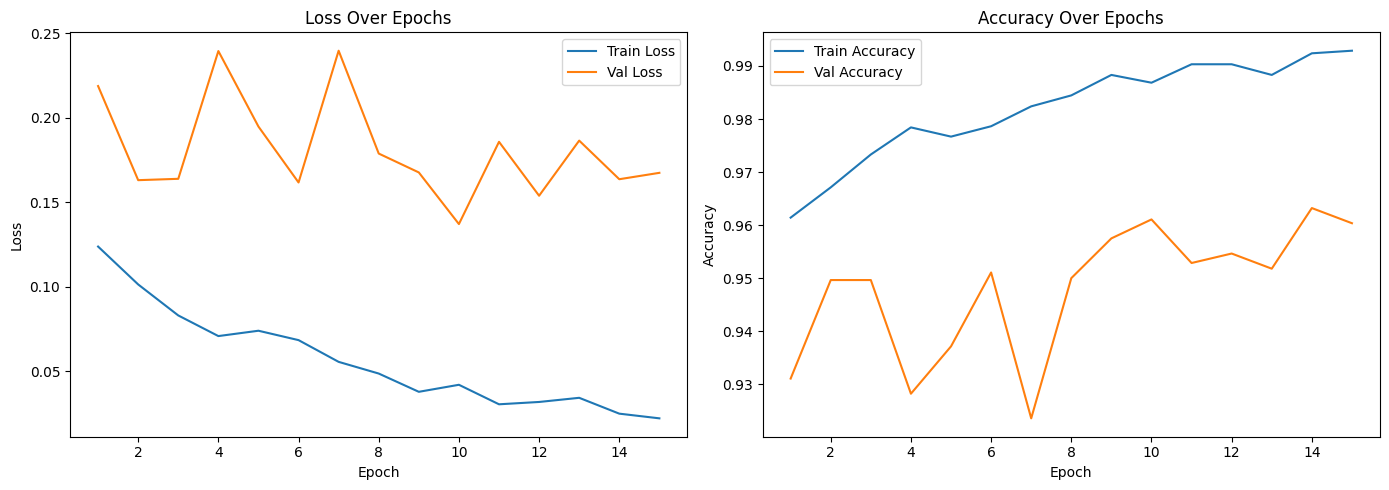

In [ ]:
plot_history(history)

In [ ]:
class_names = ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']



ROC curve

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_roc_auc(model, dataloader, class_names):
    y_true, y_scores = [], []

    model.eval()
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(torch.softmax(outputs, dim=1).cpu().numpy())

    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    y_scores = np.array(y_scores)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    for i in range(len(class_names)):
        plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Multiclass)")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show(block=True)


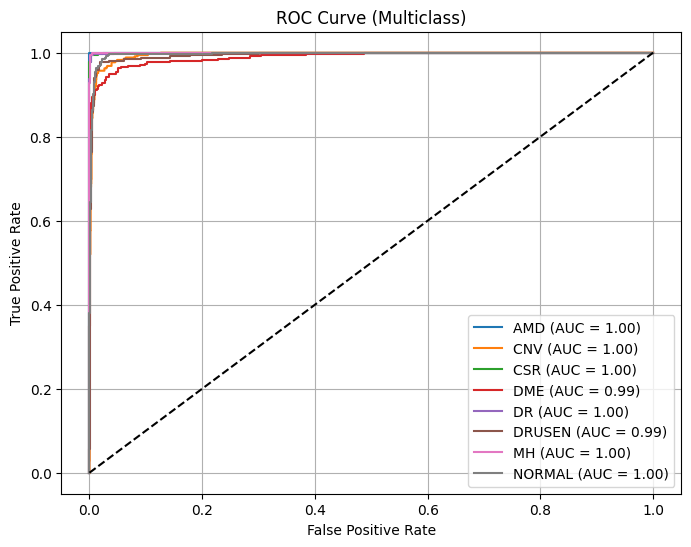

In [ ]:
plot_roc_auc(model, test_dataloader, class_names)


In [ ]:


import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, class_names, num_images=5):
    model.eval()
    images_shown = 0

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            for i in range(num_images):
                image = images[i].cpu().permute(1, 2, 0).numpy()
                true_label = class_names[labels[i].item()]
                pred_label = class_names[predicted[i].item()]

                axes[i].imshow(image)
                axes[i].set_title(f"Pred: {pred_label}\nTrue: {true_label}")
                axes[i].axis("off")

                images_shown += 1
                if images_shown == num_images:
                    break
            if images_shown == num_images:
                break

    plt.show()


Grad-CAM

In [ ]:
import torch
import torch.nn.functional as F
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet18
model = resnet18(pretrained=True).to(device)
model.train()  # Keep in train mode for Grad-CAM to support backward on cuDNN

def grad_cam(model, image_tensor, class_idx=None):
    model.zero_grad()

    # Prepare hooks
    features = []
    gradients = []

    def forward_hook(module, input, output):
        features.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # Attach hooks to the final conv layer of ResNet18
    final_conv = model.layer4[-1]
    handle_fw = final_conv.register_forward_hook(forward_hook)
    handle_bw = final_conv.register_full_backward_hook(backward_hook)

    # Forward pass
    image_tensor = image_tensor.unsqueeze(0).to(device)  # [1, C, H, W]
    output = model(image_tensor)
    if class_idx is None:
        class_idx = output.argmax().item()

    # Backward pass
    score = output[0, class_idx]
    score.backward()

    # Grad-CAM computation
    grads = gradients[0]
    fmap = features[0]
    weights = grads.mean(dim=[2, 3], keepdim=True)  # Global average pooling
    cam = (weights * fmap).sum(dim=1).squeeze()

    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / cam.max()
    cam = cam.cpu().detach().numpy()
    cam = cv2.resize(cam, (224, 224))

    # Prepare the input image for display
    img_np = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())  # Normalize for display

    # Show heatmap overlay
    plt.imshow(img_np)
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.title(f"Grad-CAM (Class {class_idx})")
    plt.axis("off")
    plt.show()

    # Cleanup
    handle_fw.remove()
    handle_bw.remove()

# ---- Run on a test sample ----
# Example: assuming test_dataloader returns (images, labels)



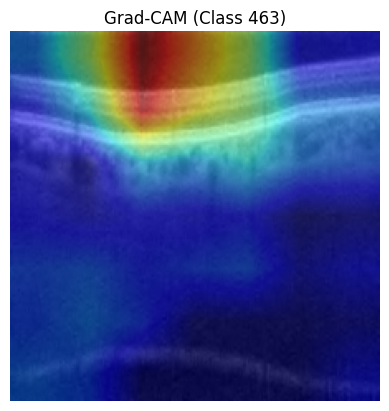

In [ ]:
sample_batch = next(iter(test_dataloader))
sample_image = sample_batch[0][0]  # First image in the batch
grad_cam(model, sample_image)

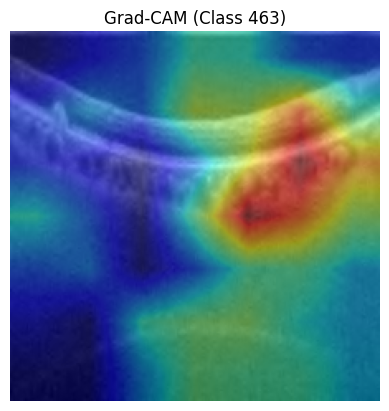

In [ ]:
sample_batch = next(iter(test_dataloader))
sample_image = sample_batch[0][7]  # First image in the batch
grad_cam(model, sample_image)

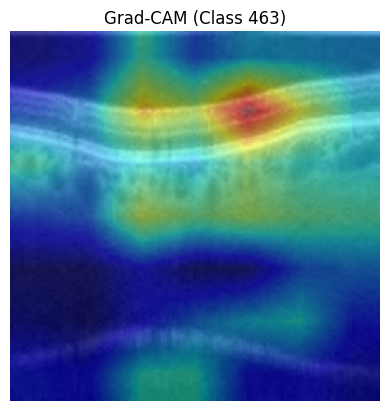

In [ ]:
sample_batch = next(iter(test_dataloader))
sample_image = sample_batch[0][2]  # First image in the batch
grad_cam(model, sample_image)

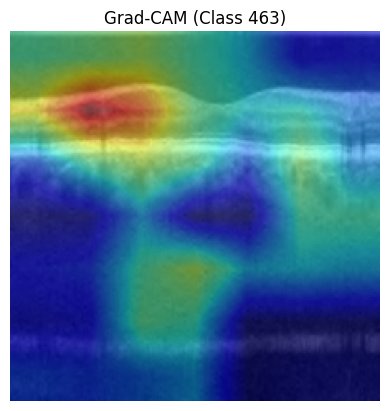

In [ ]:
sample_batch = next(iter(test_dataloader))
sample_image = sample_batch[0][3]  # First image in the batch
grad_cam(model, sample_image)

Confusion Matrix Heatmap

In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix_heatmap(model, dataloader, class_names):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Normalize the confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_normalized, annot=True, cmap="Blues", fmt=".2f", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix Heatmap")
    plt.show(block=True)



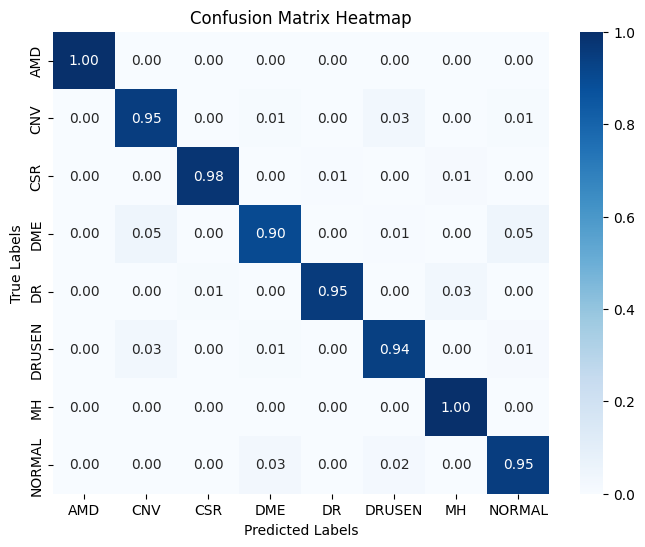

In [ ]:

plot_confusion_matrix_heatmap(model, test_dataloader, class_names)

Loss Accuracy Validation Curve

In [ ]:
import matplotlib.pyplot as plt

def plot_train_val_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()

    plt.tight_layout()
    plt.show(block=True)


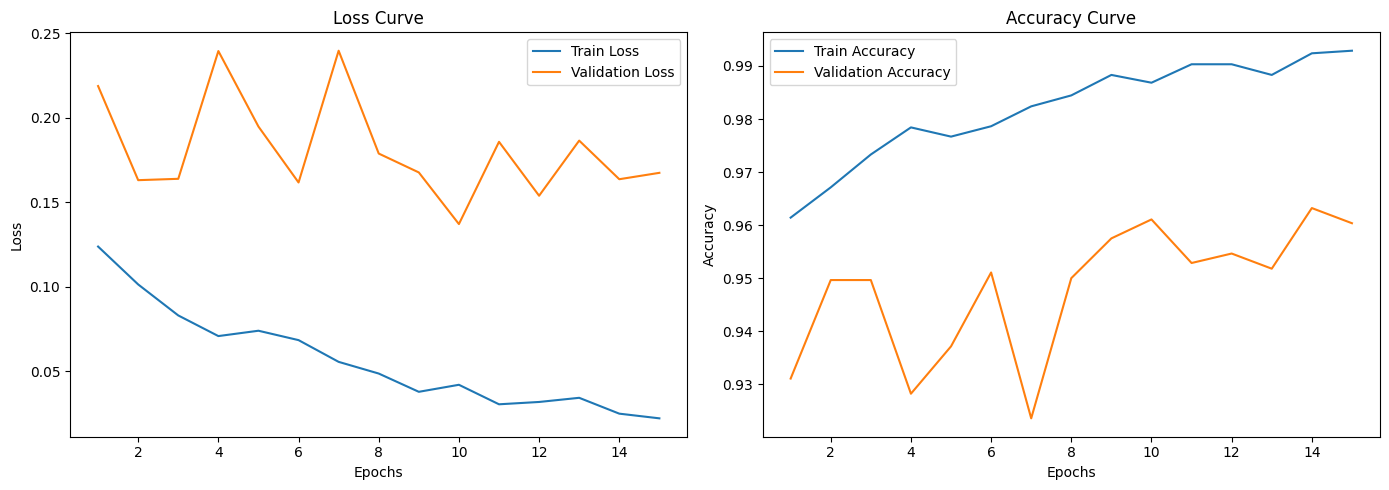

In [ ]:
plot_train_val_curves(history)
